<a href="https://colab.research.google.com/github/DangNguyenDucHuy/gnss-acquisition-tpu/blob/main/gnss_acquisition_tpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TL;DR

This Google Colab notebook is designed to perform Global Navigation Satellite System (GNSS) signal acquisition, compare the performance between traditional CPU processing and Google Colab's Tensor Processing Unit (TPU), and describe the processing architecture.

### 1. Main Objective:

The primary goals of this code file are to:
*   **GNSS Signal Acquisition:** Detect and determine basic parameters (carrier frequency, code phase) of GNSS satellites from raw Intermediate Frequency (IF) signals.
*   **Compare CPU vs. TPU Performance:** Evaluate the execution time of the signal acquisition process when using a CPU (NumPy) versus a TPU (JAX).
*   **Describe Architecture:** Visualize the GNSS signal processing flow on a JAX-GNSS-TPU co-processor system.

### 2. Key Libraries Used and Their Roles:

*   `google.colab.drive`: Used to mount Google Drive, allowing access to the GNSS signal data file (`GPSdata-DiscreteComponents-fs38_192-if9_55.bin`).
*   `numpy`: Widely used for array and numerical operations in the CPU acquisition version, as well as in utility classes (`Settings`, `Result`, `AcquisitionResult`).
*   `jax`, `jax.numpy`: Google's high-performance numerical computation library, designed to work efficiently with TPUs. JAX is used to define and optimize the `tpu_acquisition` function for parallel processing on the TPU.
*   `matplotlib.pyplot`, `matplotlib.patches`: Used to create visual diagrams of the system architecture, including hardware components and data flow.
*   `time`: Used to measure the execution time of the signal acquisition process for benchmarking purposes.
*   `warnings`: To manage and suppress Deprecation warnings during code execution.

### 3. Workflow:

The steps performed from beginning to end are as follows:

*   **Environment Setup:** Clone a GitHub repository containing source code files and install necessary libraries, especially `jax[tpu]` to enable TPU usage.
*   **Define Constants and Utility Classes:**
    *   `DATAPATH`: Specifies the path to the GNSS signal data file.
    *   `Result` class: Provide basic data structures for storing results and true positions.
*   **JAX Acquisition Function (tpu_acquisition):** An optimized function for TPU, performing steps such as local carrier wave generation, carrier wipe-off, signal correlation with CA (Code Acquisition) codes in the frequency domain, peak search, and fine frequency search.
*   **AcquisitionResult Class:** Manages the satellite acquisition process, including two methods:
    *   `acquire()`: Performs acquisition on the CPU using NumPy.
    *   `acquireTpu()`: Performs acquisition on the TPU using JAX.
*   **Settings Class:** Contains all configuration parameters for the GNSS receiver (sampling frequency, IF frequency, acquisition threshold, etc.) and provides methods to generate CA codes.
*   **Execution and Benchmarking:** Create two `Settings` objects for CPU and TPU, then call the `postProcessing()` method to run the signal acquisition process on both platforms and print the execution times.
*   **Visualization:** Generate a detailed diagram of the JAX-GNSS-TPU architecture using Matplotlib, illustrating components such as the HOST CPU, GOOGLE COLAB TPU DEVICE (HBM Memory, Systolic MXU Core), and data flow between them.

### 4. Output:

The code will return the following results:

*   **Process Messages:** Print messages about the signal acquisition process, including the PRNs (Pseudo-Random Noise) of successfully acquired satellites.
*   **Benchmark Times:** Print the time required to complete the acquisition process on both CPU and TPU (e.g., `3.5478s` for CPU and `1.2086s` for TPU).
*   **Architecture Image File:** Create and save an image file containing the benchmark result diagram.

## GNSS Acquisition

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title Setup
!git clone https://github.com/ThemeHackers/jax_tpus_benchmark_physics_simulation.git
%cd jax_tpus_benchmark_physics_simulation
# !pip install torch torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html
# !pip install "transformers<5.8"
# !pip install jax>=0.4.0 flax orbax-checkpoint clu tensorflow-datasets tensorflow-metadata protobuf
!pip install -U "jax[tpu]" -f https://storage.googleapis.com/jax-releases/libtpu_releases.html
# !pip install psutil rich matplotlib pandas jax-md scipy imageio

Cloning into 'jax_tpus_benchmark_physics_simulation'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 318 (delta 36), reused 20 (delta 20), pack-reused 270 (from 3)
Receiving objects: 100% (318/318), 163.89 KiB | 7.13 MiB/s, done.
Resolving deltas: 100% (155/155), done.
/content/jax_tpus_benchmark_physics_simulation
Looking in links: https://storage.googleapis.com/jax-releases/libtpu_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: libtpu
    Found existing installation: libtpu 0.0.21
    Uninstalling libtpu-0.0.21:
      Successfully uninstalled libtpu-0.0.21
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
#@title Constants
DATAPATH = '/content/drive/MyDrive/GPSdata-DiscreteComponents-fs38_192-if9_55.bin'

In [ ]:
#@title Jax FFT
import os
import jax.numpy as jnp
from jax import jit, vmap
from functools import partial

@partial(jit, static_argnums=(4, 5, 6, 7))
def tpu_acquisition(
    long_signal, ca_codes_f, ca_codes_raw, fb_coarse,
    samplingFreq, samples_per_code, n_fft, num_prn=32
):
    """
    Params:
        long_signal: Raw signal from ang-ten (11ms)
        ca_codes_f: CA Code table (converted to freq domain)
        ca_codes_raw: Raw 1023 chip
        fb_coarse: Freq to search
    """
    # --- Generate local carrier wave
    # t = [0, 1/fs, ..., (n-1) / fs]
    t_1ms = jnp.arange(samples_per_code) / samplingFreq

    # phi = 2 * pi * f * t
    # in which, fb_coarse - list of doppler step
    # jnp.outer(a, b) -> result[i, j] = a[i] * b[j]
    phase_matrix = 2 * jnp.pi * jnp.outer(fb_coarse, t_1ms)

    # euler: e^{j * phi} = cos(phi) + j * sin(phi)
    # carrier matrix, shape (number of freq, samples_per_code)
    carriers = jnp.exp(-1j * phase_matrix)

    # --- Parallel Correlation
    def compute_corr(sig, carrier, code_f):
        # Remove carrier to take the CA code
        mixed_sig = sig * carrier
        # Convert to freq dom
        mixed_sig_f = jnp.fft.fft(mixed_sig)
        # Multiply with ca code (already fft and conj)
        # -> IFFT back to time dom
        # -> Compute power = abs() ^ 2
        return jnp.abs(jnp.fft.ifft(mixed_sig_f * code_f)) ** 2

    # vmap to parallel
    # Run on all carriers
    vmap_freq = vmap(compute_corr, in_axes=(None, 0, None))

    # Run on all 32 prn (ca_code_f)
    vmap_all = vmap(vmap_freq, in_axes=(None, None, 0))

    # 2 consecutive 1ms blocks
    signal1 = long_signal[0:samples_per_code]
    signal2 = long_signal[samples_per_code:2 * samples_per_code]

    # corr_map of Shape (32, number of doppler freq, samples per code)
    corr_map1 = vmap_all(signal1, carriers, ca_codes_f)
    corr_map2 = vmap_all(signal2, carriers, ca_codes_f)

    # Element-wise maximum to bypass data bit transitions
    corr_map = jnp.maximum(corr_map1, corr_map2)

    # --- Search Peak
    # reshape to (32, num freq * samples per code)
    # to find peak on all prn at same time
    flat_corr = corr_map.reshape(corr_map.shape[0], -1)

    # find peak
    peak_values = jnp.max(flat_corr, axis=1)
    argmax_indices = jnp.argmax(flat_corr, axis=1)

    # find position
    # coarse_phase (0 - 38191)
    coarse_phases = argmax_indices % samples_per_code

    # coarse_freq_idx: position in fb_coarse
    coarse_freq_idx = argmax_indices // samples_per_code

    # ensure this peak much higher than second peak
    def calculate_metric(single_prn_map, p_idx, f_idx):
        samples_per_chip = samplingFreq / 1023000.0
        n = single_prn_map.shape[1]
        dist = jnp.abs(jnp.arange(n) - p_idx)
        dist = jnp.minimum(dist, n - dist)
        mask = dist > samples_per_chip
        second_peak = jnp.max(jnp.where(mask, single_prn_map[f_idx], 0.0))
        # Metric = Main peak / Second peak
        return single_prn_map[f_idx, p_idx] / second_peak

    # metric for 32 prn
    acquisition_metrics = vmap(calculate_metric)(corr_map, coarse_phases, coarse_freq_idx)

    # --- Fine Freq Search
    def fine_search_vmap(prn_idx, code_phase):
        # ca code (1023 chip) of current prn
        ca_code = ca_codes_raw[prn_idx]
        # t = [0, 1/fs, ...] -> 381920
        t_10ms = jnp.arange(10 * samples_per_code)
        code_ratio = 1023000.0 / samplingFreq
        code_indices = jnp.floor(t_10ms * code_ratio).astype(jnp.int32) % 1023
        long_ca_code = jnp.take(ca_code, code_indices)
        # de-spreading
        signal_10ms = jnp.take(long_signal, t_10ms + code_phase)
        # multiply ca code -> remove the code -> take only the carrier
        demodulated_sig = (signal_10ms - jnp.mean(signal_10ms)) * long_ca_code
        # fft
        fftx = jnp.abs(jnp.fft.fft(demodulated_sig, n=n_fft))
        # find where freq is highest
        # < nyquist freq
        half_pts = n_fft // 2
        # skip some first bins avoid noise
        fine_idx = jnp.argmax(fftx[4 : half_pts-5]) + 4
        # Convert index to Hz
        return fine_idx * samplingFreq / n_fft

    # Parallel to 32 prn
    fine_frequencies = vmap(fine_search_vmap)(jnp.arange(num_prn), coarse_phases)

    # --- Done
    # --> Doppler freq, code phase, metric (compare with acqThreshold)
    return fine_frequencies, coarse_phases, acquisition_metrics, peak_values

In [ ]:
#@title Acquisition
import jax
import jax.numpy as jnp
import numpy as np
import time

class Result(object):
    def __init__(self, settings):
        self._settings = settings
        self._results = None
        self._channels = None

    @property
    def settings(self):
        return self._settings

    @property
    def channels(self):
        assert isinstance(self._channels, np.recarray)
        return self._channels

    @property
    def results(self):
        assert isinstance(self._results, np.recarray)
        return self._results

    @results.setter
    def results(self, records):
        assert isinstance(records, np.recarray)
        self._results = records

    def plot(self):
        pass

class AcquisitionResult(Result):
    def __init__(self, settings):
        self._settings = settings
        self._results = None
        self._channels = None
        self.acquisition_time = 0

    @property
    def peakMetric(self):
        assert isinstance(self._results, np.recarray)
        return self._results.peakMetric

    @property
    def carrFreq(self):
        assert isinstance(self._results, np.recarray)
        return self._results.carrFreq

    @property
    def codePhase(self):
        assert isinstance(self._results, np.recarray)
        return self._results.codePhase

    # Parallel Code Phase Search (PCPS)
    def acquire(self, longSignal):
        # Initialization =========================================================
        settings = self._settings
        samplesPerCode = settings.samplesPerCode
        samplesPerCodeChip = round(settings.samplingFreq / settings.codeFreqBasis)

        # Take 2 consecutive sequences to avoid data bit transition
        # (cite: book, section 6.5, page 85)
        signal1 = longSignal[0:samplesPerCode]
        signal2 = longSignal[samplesPerCode:2 * samplesPerCode]
        signal0DC = longSignal - longSignal.mean()

        ts = 1.0 / settings.samplingFreq
        phasePoints = np.arange(samplesPerCode) * 2 * np.pi * ts
        numberOfFrqBins = np.int8(np.round(settings.acqSearchBand * 2) + 1)
        caCodesTable = settings.makeCaTable()

        frqBins = np.zeros(numberOfFrqBins)
        carrFreq = np.zeros(settings.num_prn)
        codePhase_ = np.zeros(settings.num_prn)
        peakMetric = np.zeros(settings.num_prn)

        # Search results of all frequency bins and code shifts (for one satellite)
        results = np.zeros((numberOfFrqBins, samplesPerCode))

        # Start benchmark
        self.acquisition_time = time.perf_counter()

        print('(', end=" ")
        # Perform search for all listed PRN numbers ...
        # for PRN in range(len(settings.acqSatelliteList)):
        for PRN in range(settings.num_prn):
            caCodeFreqDom = np.fft.fft(caCodesTable[PRN, :]).conj()
            results_single_prn = np.zeros((numberOfFrqBins, samplesPerCode))

            for frqBinIndex in range(numberOfFrqBins):
                # --- Generate carrier wave frequency grid (0.5kHz step) -----------
                frqBins[frqBinIndex] = settings.IF - \
                                    settings.acqSearchBand / 2 * 1000 + \
                                    500.0 * frqBinIndex

                sinCarr = np.sin(frqBins[frqBinIndex] * phasePoints)
                cosCarr = np.cos(frqBins[frqBinIndex] * phasePoints)

                # Convert to baseband and separate into I/Q
                I1 = sinCarr * signal1
                Q1 = cosCarr * signal1
                I2 = sinCarr * signal2
                Q2 = cosCarr * signal2

                # Correlation
                IQfreqDom1 = np.fft.fft(I1 + 1j * Q1)
                IQfreqDom2 = np.fft.fft(I2 + 1j * Q2)

                # Convolution in time domain = Multiplication in freq domain
                convCodeIQ1 = IQfreqDom1 * caCodeFreqDom
                convCodeIQ2 = IQfreqDom2 * caCodeFreqDom

                acqRes1 = abs(np.fft.ifft(convCodeIQ1)) ** 2
                acqRes2 = abs(np.fft.ifft(convCodeIQ2)) ** 2

                results_single_prn[frqBinIndex, :] = np.maximum(acqRes1, acqRes2)

            current_res = results_single_prn

            # --- Find the correlation peak and the carrier frequency --------------
            peakSize = current_res.max()
            idx = np.unravel_index(current_res.argmax(), current_res.shape)
            frequencyBinIndex, codePhase = idx

            # Take +- 1 chips around the peak
            excludeRangeIndex1 = codePhase - samplesPerCodeChip
            excludeRangeIndex2 = codePhase + samplesPerCodeChip

            if excludeRangeIndex1 <= 0:
                codePhaseRange = np.r_[excludeRangeIndex2:samplesPerCode + excludeRangeIndex1 + 1]
            elif excludeRangeIndex2 >= samplesPerCode - 1:
                codePhaseRange = np.r_[excludeRangeIndex2 - samplesPerCode:excludeRangeIndex1]
            else:
                codePhaseRange = np.r_[0:excludeRangeIndex1 + 1, excludeRangeIndex2:samplesPerCode]

            secondPeakSize = current_res[frequencyBinIndex, codePhaseRange].max()
            peakMetric[PRN] = peakSize / secondPeakSize

            if (peakSize / secondPeakSize) > settings.acqThreshold:
                caCode = settings.generateCAcode(PRN)
                codeValueIndex = np.floor(ts * np.arange(1, 10 * samplesPerCode + 1) / (1.0 / settings.codeFreqBasis))
                longCaCode = caCode[np.longlong(codeValueIndex % 1023)]
                xCarrier = signal0DC[codePhase:codePhase + 10 * samplesPerCode] * longCaCode

                fftNumPts = 8 * 2 ** (np.ceil(np.log2(len(xCarrier))))
                fftxc = np.abs(np.fft.fft(xCarrier, np.long(fftNumPts)))
                uniqFftPts = np.long(np.ceil((fftNumPts + 1) / 2.0))
                fftMax = fftxc[4:uniqFftPts - 5].max()
                fftMaxIndex = fftxc[4:uniqFftPts - 5].argmax()
                fftFreqBins = np.arange(uniqFftPts) * settings.samplingFreq / fftNumPts

                carrFreq[PRN] = fftFreqBins[fftMaxIndex]
                codePhase_[PRN] = codePhase

                print('%02d ' % (PRN + 1), end=" ")
            else:
                # --- No signal with this PRN --------------------------------------
                # print('. ')
                pass

        print(')\n')

        # === Acquisition is over ==================================================

        self.acquisition_time = time.perf_counter() - self.acquisition_time

        acqResults = np.core.records.fromarrays(
            [carrFreq, codePhase_, peakMetric],
            names='carrFreq,codePhase,peakMetric'
        )
        self._results = acqResults
        return

    def acquireTpu(self, longSignal):
        # --- Config
        settings = self._settings

        # To fine freq search on 10ms signal
        # -> Find log2 (better for fft)
        # padding by *2
        n_fft = int(2**np.ceil(np.log2(10 * settings.samplesPerCode)) * 2)

        # Convert to jax (_j)
        longSignal_j = jnp.array(longSignal, dtype=jnp.float32)
        # fft for ca code
        ca_f_j = jnp.conj(jnp.fft.fft(jnp.array(settings.makeCaTable(), dtype=jnp.float32)))
        # generate offline 32 prn (1 prn = 1023 numbers of 1 and -1)
        ca_raw_j = jnp.array(settings.ca_codes_table_raw, dtype=jnp.float32)
        # Check for each doppler step
        # acqSearchBand = 10.0 -> IF +- 5000 Hz, step 500 Hz
        fb_coarse = jnp.arange(
            settings.IF - settings.acqSearchBand / 2 * 1000,
            settings.IF + settings.acqSearchBand / 2 * 1000 + 500,
            500
        )

        # --- Run
        self.acquisition_time = time.perf_counter()

        fine_freqs, code_phases, metrics, peak_values = tpu_acquisition(
            longSignal_j, ca_f_j, ca_raw_j, fb_coarse,
            float(settings.samplingFreq), int(settings.samplesPerCode), int(n_fft),
            num_prn=settings.num_prn
        )
        fine_freqs.block_until_ready()

        # --- Convert back to CPU
        carrFreq = np.array(fine_freqs)
        codePhase_ = np.array(code_phases)
        peakMetric = np.array(metrics)

        print("(", end=" ")
        for PRN in range(settings.num_prn):
            if peakMetric[PRN] > settings.acqThreshold:
                print('%02d ' % (PRN + 1), end=" ")
            else:
                carrFreq[PRN] = 0
                codePhase_[PRN] = 0

        print(")")

        self.acquisition_time = time.perf_counter() - self.acquisition_time

        # --- Save result
        acqResults = np.core.records.fromarrays(
            [carrFreq, codePhase_, peakMetric],
            names='carrFreq,codePhase,peakMetric'
        )
        self._results = acqResults
        return

In [ ]:
#@title Settings
import datetime
import numpy as np

class Settings(object):
    def __init__(self, filename, device):
        # Processing settings ====================================================
        self.msToProcess = 37000.0
        self.numberOfChannels = 8
        self.skipNumberOfBytes = 0

        # Raw signal file name and other parameter =============================
        self.fileName = filename
        self.dataType = 'int8'
        self.IF = 9548000.0
        self.samplingFreq = 38192000.0
        self.codeFreqBasis = 1023000.0
        self.codeLength = 1023

        # Acquisition settings =================================================
        self.skipAcquisition = False
        self.acqSatelliteList = range(1, 33)
        self.acqSearchBand = 10.0
        self.acqThreshold = 4.5

        # Constants ============================================================
        self._c = 299792458.0
        self._startOffset = 68.802

        # Benchmark settings ===================================================
        self.num_prn = 32
        # Raw CA code table for Fine Freq Search
        self.ca_codes_table_raw = np.array(
            [self.generateCAcode(i) for i in range(self.num_prn)],
            dtype=np.float32
        )
        self.device = device
        self.acquisition_time = 0


    @property
    def c(self):
        return self._c

    @property
    def startOffset(self):
        return self._startOffset

    @property
    def samplesPerCode(self):
        return np.long(np.round(self.samplingFreq / (self.codeFreqBasis / self.codeLength)))

    def makeCaTable(self):
        samplesPerCode = self.samplesPerCode
        caCodesTable = np.zeros((self.num_prn, samplesPerCode))
        ts = 1.0 / self.samplingFreq
        tc = 1.0 / self.codeFreqBasis
        for PRN in range(self.num_prn):
            caCode = self.generateCAcode(PRN)
            codeValueIndex = np.ceil(ts * np.arange(1, samplesPerCode + 1) / tc) - 1
            codeValueIndex = np.longlong(codeValueIndex)
            codeValueIndex[-1] = 1022
            caCodesTable[PRN] = caCode[codeValueIndex]
        return caCodesTable

    def generateCAcode(self, prn):
        assert prn in range(0, 32)
        g2s = [5, 6, 7, 8, 17, 18, 139, 140, 141, 251,
               252, 254, 255, 256, 257, 258, 469, 470, 471, 472,
               473, 474, 509, 512, 513, 514, 515, 516, 859, 860,
               861, 862,
               145, 175, 52, 21, 237, 235, 886, 657, 634, 762, 355, 1012, 176, 603, 130, 359, 595, 68, 386]
        g2shift = g2s[prn]
        g1 = np.zeros(1023)
        reg = -1 * np.ones(10)
        for i in range(1023):
            g1[i] = reg[-1]
            saveBit = reg[2] * reg[9]
            reg[1:] = reg[:-1]
            reg[0] = saveBit
        g2 = np.zeros(1023)
        reg = -1 * np.ones(10)
        for i in range(1023):
            g2[i] = reg[-1]
            saveBit = reg[1] * reg[2] * reg[5] * reg[7] * reg[8] * reg[9]
            reg[1:] = reg[:-1]
            reg[0] = saveBit
        g2 = np.r_[g2[1023 - g2shift:], g2[:1023 - g2shift]]
        CAcode = -g1 * g2
        return CAcode

    @staticmethod
    def calcLoopCoef(LBW, zeta, k):
        Wn = LBW * 8.0 * zeta / (4.0 * zeta ** 2 + 1)
        tau1 = k / (Wn * Wn)
        tau2 = 2.0 * zeta / Wn
        return tau1, tau2

    def postProcessing(self, fileNameStr=None):
        print('Starting processing...')
        settings = self
        if not fileNameStr:
            fileNameStr = settings.fileName
        if not isinstance(fileNameStr, str):
            raise TypeError('File name must be a string')
        try:
            with open(fileNameStr, 'rb') as fid:
                fid.seek(settings.skipNumberOfBytes, 0)
                if not settings.skipAcquisition:  # or 'acqResults' not in globals():
                    samplesPerCode = settings.samplesPerCode
                    data = np.fromfile(fid, settings.dataType, 11 * samplesPerCode)
                    print('   Acquiring satellites...')
                    acqResults = AcquisitionResult(settings)

                    # Run acquisition
                    if self.device == 'cpu':
                        acqResults.acquire(data)
                    elif self.device == 'tpu':
                        acqResults.acquireTpu(data)

                    # acqResults.plot()

                    # Implement time
                    print(f"----- Benchmark time ({self.device.upper()}) -----")
                    print(f"{acqResults.acquisition_time:.4f}s")

                    self.acquisition_time = acqResults.acquisition_time

        except IOError as e:
            # Error while opening the data file.
            print('Unable to read file "%s": %s.' % (settings.fileName, e))


## Benchmark

In [ ]:
#@title Sample run
settings_cpu = Settings(filename=DATAPATH, device='cpu')
settings_tpu = Settings(filename=DATAPATH, device='tpu')

# Only acquisition
settings_cpu.postProcessing()

print("\n(Warmup)")
settings_tpu.postProcessing()

settings_tpu.postProcessing()

Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.5478s

(Warmup)
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )
----- Benchmark time (TPU) -----
33.0831s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )
----- Benchmark time (TPU) -----
1.2086s


Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7578s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7512s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7597s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7681s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7659s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7508s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7700s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7800s
Starting processing...
   Acquiring satellites...
( 18  21  )

----- Benchmark time (CPU) -----
0.7853s
Starting processing...
   Acquiring satellites...
( 18  21  )

-

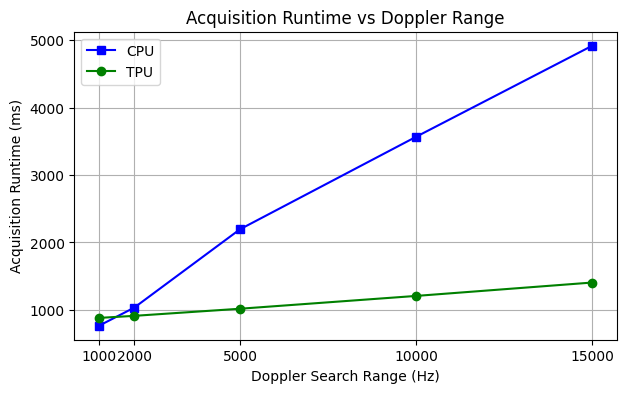

In [ ]:
#@title Doppler ranges
import time
import numpy as np
import matplotlib.pyplot as plt

num_runs = 10
doppler_ranges = [1000, 2000, 5000, 10000, 15000]   # kHz
benchmark_times = []

for device in ['cpu', 'tpu']:
    device_times = []
    for doppler_range in doppler_ranges:
        settings = Settings(filename=DATAPATH, device=device)
        settings.acqSearchBand = doppler_range / 1000.0

        # Warm up
        if device == 'tpu':
            settings.postProcessing()

        bench = []
        for _ in range(num_runs):
            settings.postProcessing()
            bench.append(settings.acquisition_time * 1000)  # ms

        device_times.append(np.mean(bench))

    print(
        f"\n\n===== Benchmark time ({device.upper()}) ====="
        f"\nDoppler range: +- {doppler_range} kHz"
        f"\nNumber of runs: {num_runs}"
        f"\nAverage time: {np.mean(device_times)}"
    )

    benchmark_times.append(device_times)


# Visualize
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    doppler_ranges,
    benchmark_times[0],
    marker="s",
    color="blue",
    label="CPU"
)
ax.plot(
    doppler_ranges,
    benchmark_times[1],
    marker="o",
    color="green",
    label="TPU"
)

ax.set_xlabel("Doppler Search Range (Hz)")
ax.set_xticks(doppler_ranges)
ax.set_ylabel("Acquisition Runtime (ms)")
ax.set_title("Acquisition Runtime vs Doppler Range")
ax.grid(True)
ax.legend()

plt.savefig(
    f"doppler_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0909s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0923s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0901s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0914s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0953s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0933s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0924s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0940s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0922s
Starting processing...
   Acquiring satellites...
( )

----- Benchmark time (CPU) -----
0.0918s
Starting processing...
   Acquiring sate

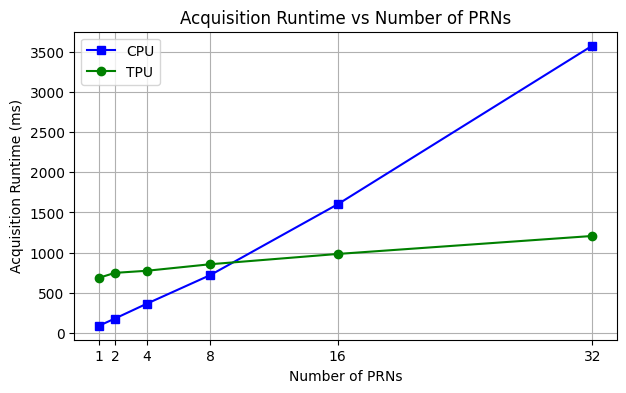

In [ ]:
#@title Number of PRNs
import time
import numpy as np
import matplotlib.pyplot as plt

num_runs = 10
num_prns = [1, 2, 4, 8, 16, 32]
benchmark_times = []

for device in ['cpu', 'tpu']:
    device_times = []
    for num_prn in num_prns:
        settings = Settings(filename=DATAPATH, device=device)
        settings.num_prn = num_prn

        # Warm up
        if device == 'tpu':
            settings.postProcessing()

        bench = []
        for _ in range(num_runs):
            settings.postProcessing()
            bench.append(settings.acquisition_time * 1000)  # ms

        device_times.append(np.mean(bench))

    print(
        f"\n\n===== Benchmark time ({device.upper()}) ====="
        f"\nNumber of PRNs: {num_prn}"
        f"\nNumber of runs: {num_runs}"
        f"\nAverage time: {np.mean(device_times)}"
    )

    benchmark_times.append(device_times)


# Visualize
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    num_prns,
    benchmark_times[0],
    marker="s",
    color="blue",
    label="CPU"
)
ax.plot(
    num_prns,
    benchmark_times[1],
    marker="o",
    color="green",
    label="TPU"
)

ax.set_xlabel("Number of PRNs")
ax.set_ylabel("Acquisition Runtime (ms)")
ax.set_xticks(num_prns)
ax.set_title("Acquisition Runtime vs Number of PRNs")
ax.grid(True)
ax.legend()

plt.savefig(
    f"prn_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

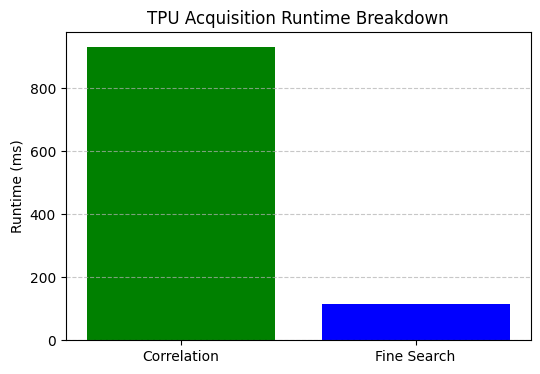

Correlation : 931.55 ms
Fine Search : 114.80 ms


In [ ]:
#@title TPU Runtime breakdown
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from jax import jit, vmap
import jax.numpy as jnp

num_runs = 10

@partial(jit, static_argnums=(3, 4))
def tpu_corr_only(long_signal, ca_codes_f, fb_coarse, samplingFreq, samples_per_code):
    t_1ms = jnp.arange(samples_per_code) / samplingFreq
    phase_matrix = 2 * jnp.pi * jnp.outer(fb_coarse, t_1ms)
    carriers = jnp.exp(1j * phase_matrix)

    def compute_corr(sig, carrier, code_f):
        mixed_sig = sig * carrier
        mixed_sig_f = jnp.fft.fft(mixed_sig)
        return jnp.abs(jnp.fft.ifft(mixed_sig_f * code_f)) ** 2

    vmap_freq = vmap(compute_corr, in_axes=(None, 0, None))
    vmap_all = vmap(vmap_freq, in_axes=(None, None, 0))
    signal1 = long_signal[0:samples_per_code]
    signal2 = long_signal[samples_per_code:2 * samples_per_code]
    corr_map1 = vmap_all(signal1, carriers, ca_codes_f)
    corr_map2 = vmap_all(signal2, carriers, ca_codes_f)
    corr_map = jnp.maximum(corr_map1, corr_map2)
    return corr_map

settings_tpu = Settings(filename=DATAPATH, device='tpu')
samples_per_code = int(settings_tpu.samplesPerCode)
sampling_freq_val = float(settings_tpu.samplingFreq)

with open(DATAPATH, "rb") as f:
    signal = np.fromfile(f, settings_tpu.dataType, 11 * samples_per_code)

longSignal_j = jnp.array(signal)
ca_f_j = jnp.conj(jnp.fft.fft(jnp.array(
    settings_tpu.makeCaTable(),
    dtype=jnp.float32
)))
fb_coarse = jnp.arange(
    settings_tpu.IF - settings_tpu.acqSearchBand/2*1000,
    settings_tpu.IF + settings_tpu.acqSearchBand/2*1000 + 500,
    500
)
n_fft = int(2**np.ceil(np.log2(10 * samples_per_code)) * 2)
ca_raw_j = jnp.array(settings_tpu.ca_codes_table_raw, dtype=jnp.float32)


# Warm up
corr = tpu_corr_only(longSignal_j, ca_f_j, fb_coarse, sampling_freq_val, samples_per_code)
corr.block_until_ready()

full = tpu_acquisition(
    longSignal_j, ca_f_j, ca_raw_j, fb_coarse,
    sampling_freq_val, samples_per_code, n_fft
)
full[0].block_until_ready()


# Benchmark
corr_times = []
full_times = []

for _ in range(num_runs):
    t0 = time.perf_counter()
    corr = tpu_corr_only(
        longSignal_j, ca_f_j, fb_coarse,
        sampling_freq_val, samples_per_code
    )
    corr.block_until_ready()
    corr_times.append(time.perf_counter() - t0)

for _ in range(num_runs):
    t0 = time.perf_counter()
    result = tpu_acquisition(
        longSignal_j, ca_f_j, ca_raw_j, fb_coarse,
        sampling_freq_val, samples_per_code, n_fft
    )
    result[0].block_until_ready()
    full_times.append(time.perf_counter() - t0)

corr_time = np.mean(corr_times)
full_time = np.mean(full_times)
fine_time = max(0.0, full_time - corr_time)


# Visualize
plt.figure(figsize=(6,4))
plt.bar(
    ["Correlation", "Fine Search"],
    [corr_time*1000, fine_time*1000],
    color=['green', 'blue']
)
plt.ylabel("Runtime (ms)")
plt.title("TPU Acquisition Runtime Breakdown")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig(
    "tpu_breakdown.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"Correlation : {corr_time*1000:.2f} ms")
print(f"Fine Search : {fine_time*1000:.2f} ms")

Starting processing...
   Acquiring satellites...
( 15  18  21  22  )
----- Benchmark time (TPU) -----
1.2083s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.5740s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.5481s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.5044s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.6259s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.5188s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.6138s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3.6051s
Starting processing...
   Acquiring satellites...
( 15  18  21  22  )

----- Benchmark time (CPU) -----
3

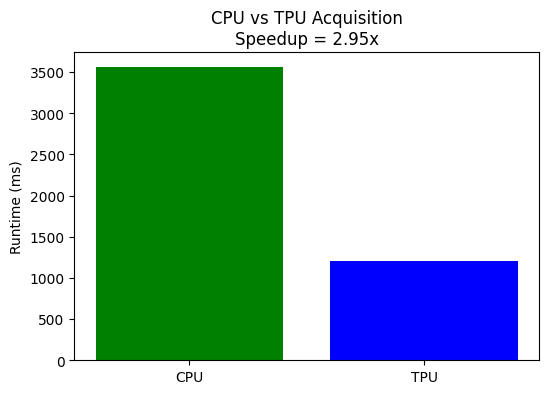

In [ ]:
#@title CPU vs TPU
settings_cpu = Settings(filename=DATAPATH, device='cpu')
settings_tpu = Settings(filename=DATAPATH, device='tpu')

# Warm up
settings_tpu.postProcessing()

num_runs = 10

cpu_times = []
for _ in range(num_runs):
    settings_cpu.postProcessing()
    cpu_times.append(settings_cpu.acquisition_time * 1000)  # ms

tpu_times = []
for _ in range(num_runs):
    settings_tpu.postProcessing()
    tpu_times.append(settings_tpu.acquisition_time * 1000)  # ms


cpu_time = np.mean(cpu_times)
tpu_time = np.mean(tpu_times)
speedup = cpu_time / tpu_time

print(f"CPU     : {cpu_time:.4f} s")
print(f"TPU     : {tpu_time:.4f} s")
print(f"Speedup : {speedup:.2f}x")


# Visualize
plt.figure(figsize=(6,4))

plt.bar(
    ["CPU", "TPU"],
    [cpu_time, tpu_time],
    color=['green', 'blue']
)

plt.ylabel("Runtime (ms)")
plt.title(f"CPU vs TPU Acquisition\nSpeedup = {speedup:.2f}x")

plt.savefig(
    "speedup_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()